In [22]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from  langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.prebuilt import ToolNode,tools_condition
import time

In [23]:
load_dotenv()

True

In [3]:
#initiating llm
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
#Loading The pdf or external resource
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [5]:
#Splitting the loaded resource
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000,chunk_overlap = 200)
chunks = splitter.split_documents(docs)

In [19]:
total_chunks = len(chunks)

In [21]:
#Generating embeddings using GoogleAIEmbedding library
embeddings = GoogleGenerativeAIEmbeddings(model = "gemini-embedding-001",task_type="retrieval_document")

In [ ]:
#defining batch size - as Faiss will push all data at once - and google free teir allows 100 RPM limit 

# A batch size of 50 documents means 1 API call per batch in FAISS
BATCH_SIZE = 50

# 15 seconds between batches guarantees you stay safely under 100 requests per minute
COOLDOWN_SECONDS = 15 
vector_store = None

print(f"Starting ingestion of {total_chunks} chunks...")

# 3. Loop through your chunks and build the index incrementally

for i in range(0,total_chunks,BATCH_SIZE):
    batch = chunks[i:i+BATCH_SIZE]
    current_batch_num = (i // BATCH_SIZE) + 1
    total_batches = -(total_chunks // -BATCH_SIZE)  # Ceiling division

    print(f"Processing batch {current_batch_num}/{total_batches}...")
    if vector_store is None:
        # Initialize the FAISS database with the first batch
        vector_store = FAISS.from_documents(batch, embeddings)
        #adding force break after one batch so to avoid entire book processing
        break
    else:
        # Append subsequent batches to the existing database
        vector_store.add_documents(batch)  
    
    # Apply cooldown pause for all batches except the final one
    if i + BATCH_SIZE < total_chunks:
        print(f"Batch {current_batch_num} complete. Pausing for {COOLDOWN_SECONDS}s to protect free tier quota...")
        time.sleep(COOLDOWN_SECONDS)  
print("Successfully created FAISS vector store without hitting rate limits!")

Starting ingestion of 973 chunks...
Processing batch 1/20...
Successfully created FAISS vector store without hitting rate limits!


In [ ]:
'''
#Generating Embeddings
#embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview",task_type="retrieval_document",output_dimensionality=768)
embeddings = GoogleGenerativeAIEmbeddings(model= "gemini-embedding-001",task_type="retrieval_document")
vector_store = FAISS.from_documents(chunks,embeddings)
'''

In [27]:
vector_store

In [28]:
#Retriever
retriever = vector_store.as_retriever(search_type ="similarity",search_kwargs ={'k':4})

In [36]:
retriever

VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001A170F91340>, search_kwargs={'k': 4})

In [29]:
#defining tool
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [30]:
#adding tools
tools = [rag_tool]
#binding tools with llm
llm_with_tools = llm.bind_tools(tools)


In [31]:
#defining state
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]
    

In [32]:
def chat_node(state:ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages":[response]}


In [14]:
#defining tool node
tool_node = ToolNode(tools)

In [33]:
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot = graph.compile()

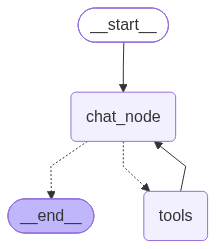

In [16]:
chatbot

In [37]:
result = chatbot.invoke({
    'messages': [
        HumanMessage(
            content = "Using the pdf notes, explain how to find the ideal value of ML"
        )
    ]
})

In [40]:
print(result['messages'][-1].content[0]["text"])

The term "ideal value of ML" is not a standard concept in machine learning. However, if you are referring to finding the ideal parameters for a machine learning model, techniques like **Grid Search** and **Cross-Validation** are commonly used.

Grid Search systematically works through multiple combinations of parameter tunes, evaluating a model for each to determine which parameters perform best. Cross-validation is often used in conjunction with Grid Search to ensure that the chosen parameters generalize well to new, unseen data and to prevent overfitting.

The document mentions:
*   **Grid Search**
*   **Simple Grid Search**
*   **The Danger of Overfitting the Parameters and the Validation Set**
*   **Grid Search with Cross-Validation**

These sections would likely elaborate on how to find the optimal settings (or "ideal values" for parameters) for your machine learning models.
